# 06 — Drought Detection + Statistical Significance


Dataset: Superstore Sales (monthly resampled)  


## 0. Imports & Setup

In [1]:
import zipfile, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 10,
})
os.makedirs('figures', exist_ok=True)

print('Imports OK.')

Imports OK.


## 1. Data Loading — same as all previous notebooks

In [2]:
with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:/Users/tavis/Downloads/archive (1)')

df = pd.read_csv(
    r'C:/Users/tavis/Downloads/archive (1)/Sample - Superstore.csv',
    encoding='ISO-8859-1'
)
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.resample('ME', on='Order Date')['Sales'].sum()

split = int(len(monthly) * 0.8)
train = monthly[:split]
test  = monthly[split:]

print(f'Total months : {len(monthly)}')
print(f'Test  months : {len(test)}  ({test.index[0].date()} to {test.index[-1].date()})')

Total months : 48
Test  months : 10  (2017-03-31 to 2017-12-31)


## 2. evaluate() Helper

In [4]:
def evaluate(actual, predicted):
    actual    = np.array(actual,    dtype=float).flatten()
    predicted = np.array(predicted, dtype=float).flatten()
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

## 3. Re-fit All Models to get forecast arrays on test set

In [5]:
from pmdarima import auto_arima
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# ── ARIMA ────────────────────────────────────────────────────────────────────
print('Fitting ARIMA...')
model_arima = auto_arima(
    train, seasonal=True, m=12, stepwise=True,
    suppress_warnings=True, information_criterion='aic',
    max_p=3, max_q=3, max_P=2, max_Q=2, D=0, error_action='ignore'
)
forecast_arima = model_arima.predict(n_periods=len(test))
print('  ARIMA done.')

# ── ETS ──────────────────────────────────────────────────────────────────────
print('Fitting ETS...')
model_ets    = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_ets = model_ets.forecast(len(test)).values
print('  ETS done.')

# ── Prophet + Holidays ───────────────────────────────────────────────────────
print('Fitting Prophet + Holidays...')
df_prophet = monthly.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
train_p = df_prophet.iloc[:split].copy()
test_p  = df_prophet.iloc[split:].copy()
m_h = Prophet(yearly_seasonality=True, weekly_seasonality=False,
               daily_seasonality=False, holidays_prior_scale=10)
m_h.add_country_holidays(country_name='IN')
m_h.fit(train_p)
future_h = m_h.make_future_dataframe(periods=len(test_p), freq='ME')
fcast_h  = m_h.predict(future_h)
forecast_prophet = fcast_h[fcast_h['ds'].isin(test_p['ds'])]['yhat'].values
print('  Prophet done.')

# ── XGBoost ──────────────────────────────────────────────────────────────────
print('Fitting XGBoost...')
df_ml = monthly.reset_index()
df_ml.columns = ['Order Date', 'Sales']
df_ml['lag_1']          = df_ml['Sales'].shift(1)
df_ml['lag_2']          = df_ml['Sales'].shift(2)
df_ml['lag_4']          = df_ml['Sales'].shift(4)
df_ml['lag_12']         = df_ml['Sales'].shift(12)
df_ml['rolling_mean_4'] = df_ml['Sales'].rolling(4).mean()
df_ml['roll_std_4']     = df_ml['Sales'].rolling(4).std()
df_ml['roll_mean_12']   = df_ml['Sales'].rolling(12).mean()
df_ml['month']          = df_ml['Order Date'].dt.month
df_ml['quarter']        = df_ml['Order Date'].dt.quarter
df_ml['week']           = df_ml['Order Date'].dt.isocalendar().week
df_ml['holiday_flag']   = 0
df_ml = df_ml.dropna().copy()
features_xgb = ['lag_1','lag_2','lag_4','lag_12',
                 'rolling_mean_4','roll_std_4','roll_mean_12',
                 'month','quarter','week','holiday_flag']
sp_xgb = int(len(df_ml) * 0.8)
X_xgb_train = df_ml[features_xgb][:sp_xgb]
X_xgb_test  = df_ml[features_xgb][sp_xgb:]
y_xgb_train = df_ml['Sales'][:sp_xgb]
y_xgb_test  = df_ml['Sales'][sp_xgb:]
xgb_test_dates = df_ml['Order Date'].values[sp_xgb:]
model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_xgb_train, y_xgb_train)
pred_xgb = model_xgb.predict(X_xgb_test)
print('  XGBoost done.')

# ── LSTM ─────────────────────────────────────────────────────────────────────
print('Fitting LSTM...')
class DonationLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

SEQ_LEN = 12
scaler_lstm = MinMaxScaler()
scaled = scaler_lstm.fit_transform(monthly.values.reshape(-1, 1))

def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y).reshape(-1, 1)

X_all, y_all  = create_sequences(scaled, seq_len=SEQ_LEN)
sp_lstm       = int(len(X_all) * 0.8)
X_train_t = torch.FloatTensor(X_all[:sp_lstm])
X_test_t  = torch.FloatTensor(X_all[sp_lstm:])
y_train_t = torch.FloatTensor(y_all[:sp_lstm])
y_lstm_actual = scaler_lstm.inverse_transform(y_all[sp_lstm:]).flatten()
lstm_test_dates = monthly.index[SEQ_LEN + sp_lstm:]

model_lstm = DonationLSTM()
opt  = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
crit = nn.MSELoss()
for epoch in range(100):
    model_lstm.train(); opt.zero_grad()
    loss = crit(model_lstm(X_train_t), y_train_t)
    loss.backward(); opt.step()

model_lstm.eval()
with torch.no_grad():
    pred_lstm = scaler_lstm.inverse_transform(model_lstm(X_test_t).numpy()).flatten()
print('  LSTM done.')

print('\nAll 5 models fitted and forecast arrays ready.')

Importing plotly failed. Interactive plots will not work.


Fitting ARIMA...
  ARIMA done.
Fitting ETS...
  ETS done.
Fitting Prophet + Holidays...


11:26:45 - cmdstanpy - INFO - Chain [1] start processing
11:26:45 - cmdstanpy - INFO - Chain [1] done processing


  Prophet done.
Fitting XGBoost...
  XGBoost done.
Fitting LSTM...
  LSTM done.

All 5 models fitted and forecast arrays ready.


## 4. Build results dict + Identify Best Model

In [11]:


n_test = len(test)

pred_xgb_algn = np.array(pred_xgb[-n_test:])
pred_lstm_algn = np.array(pred_lstm[-n_test:])

y_test_vals = np.array(test.values)


pred_xgb_algn = np.nan_to_num(pred_xgb_algn)
pred_lstm_algn = np.nan_to_num(pred_lstm_algn)


min_len = min(
    len(y_test_vals),
    len(pred_xgb_algn),
    len(pred_lstm_algn),
    len(forecast_arima),
    len(forecast_ets),
    len(forecast_prophet)
)

y_test_vals     = y_test_vals[-min_len:]
forecast_arima  = np.array(forecast_arima)[-min_len:]
forecast_ets    = np.array(forecast_ets)[-min_len:]
forecast_prophet= np.array(forecast_prophet)[-min_len:]
pred_xgb_algn   = pred_xgb_algn[-min_len:]
pred_lstm_algn  = pred_lstm_algn[-min_len:]



results = {
    'ARIMA'            : evaluate(y_test_vals, forecast_arima),
    'ETS'              : evaluate(y_test_vals, forecast_ets),
    'Prophet+Holidays' : evaluate(y_test_vals, forecast_prophet),
    'XGBoost'          : evaluate(y_test_vals, pred_xgb_algn),
    'LSTM'             : evaluate(y_test_vals, pred_lstm_algn)
}



results_df = pd.DataFrame(results).T.round(2)

results_df = results_df.sort_values('MAPE')

best_model_name   = results_df['MAPE'].idxmin()
second_model_name = results_df['MAPE'].nsmallest(2).index[1]



model_preds = {
    'ARIMA'            : forecast_arima,
    'ETS'              : forecast_ets,
    'Prophet+Holidays' : forecast_prophet,
    'XGBoost'          : pred_xgb_algn,
    'LSTM'             : pred_lstm_algn
}

best_forecast   = model_preds[best_model_name]
second_forecast = model_preds[second_model_name]

print(results_df)

print(f"\nBest model : {best_model_name}")
print(f"Second best: {second_model_name}")

                      RMSE       MAE   MAPE
ETS               12677.22  11451.49  16.36
Prophet+Holidays  16335.74  13085.30  17.45
XGBoost           16364.50  13418.58  17.84
ARIMA             27751.03  22117.39  27.55
LSTM              36479.24  27765.70  31.94

Best model : ETS
Second best: Prophet+Holidays


## 5. Drought Detection Framework — RQ3

In [16]:
WINDOW = 8     
THRESH = 0.70   


rolling_avg = monthly.rolling(WINDOW).mean()
threshold   = rolling_avg * THRESH


actual_drought_weeks = monthly[monthly < threshold]


forecast_series = pd.Series(best_forecast, index=test.index[:len(best_forecast)])
threshold_test = threshold[forecast_series.index]
forecast_drought_mask = forecast_series < threshold_test
drought_flags         = forecast_series[forecast_drought_mask]


actual_in_test = actual_drought_weeks[actual_drought_weeks.index.isin(test.index)]


correct_flags = drought_flags.index.isin(actual_in_test.index).sum()
precision = (correct_flags / len(drought_flags))  if len(drought_flags) > 0  else 0.0
recall    = (correct_flags / len(actual_in_test))  if len(actual_in_test) > 0 else 0.0

print(f'Drought definition   : below {THRESH*100:.0f}% of {WINDOW}-month rolling mean')
print(f'Drought months (full history) : {len(actual_drought_weeks)}')
print(f'Drought months (test period)  : {len(actual_in_test)}')
print(f'Flagged by {best_model_name}   : {len(drought_flags)}')
print(f'Correct flags        : {correct_flags}')
print(f'Precision            : {precision:.2%}')
print(f'Recall               : {recall:.2%}')

Drought definition   : below 70% of 8-month rolling mean
Drought months (full history) : 7
Drought months (test period)  : 1
Flagged by ETS   : 0
Correct flags        : 0
Precision            : 0.00%
Recall               : 0.00%


## 6. Drought Detection Figure

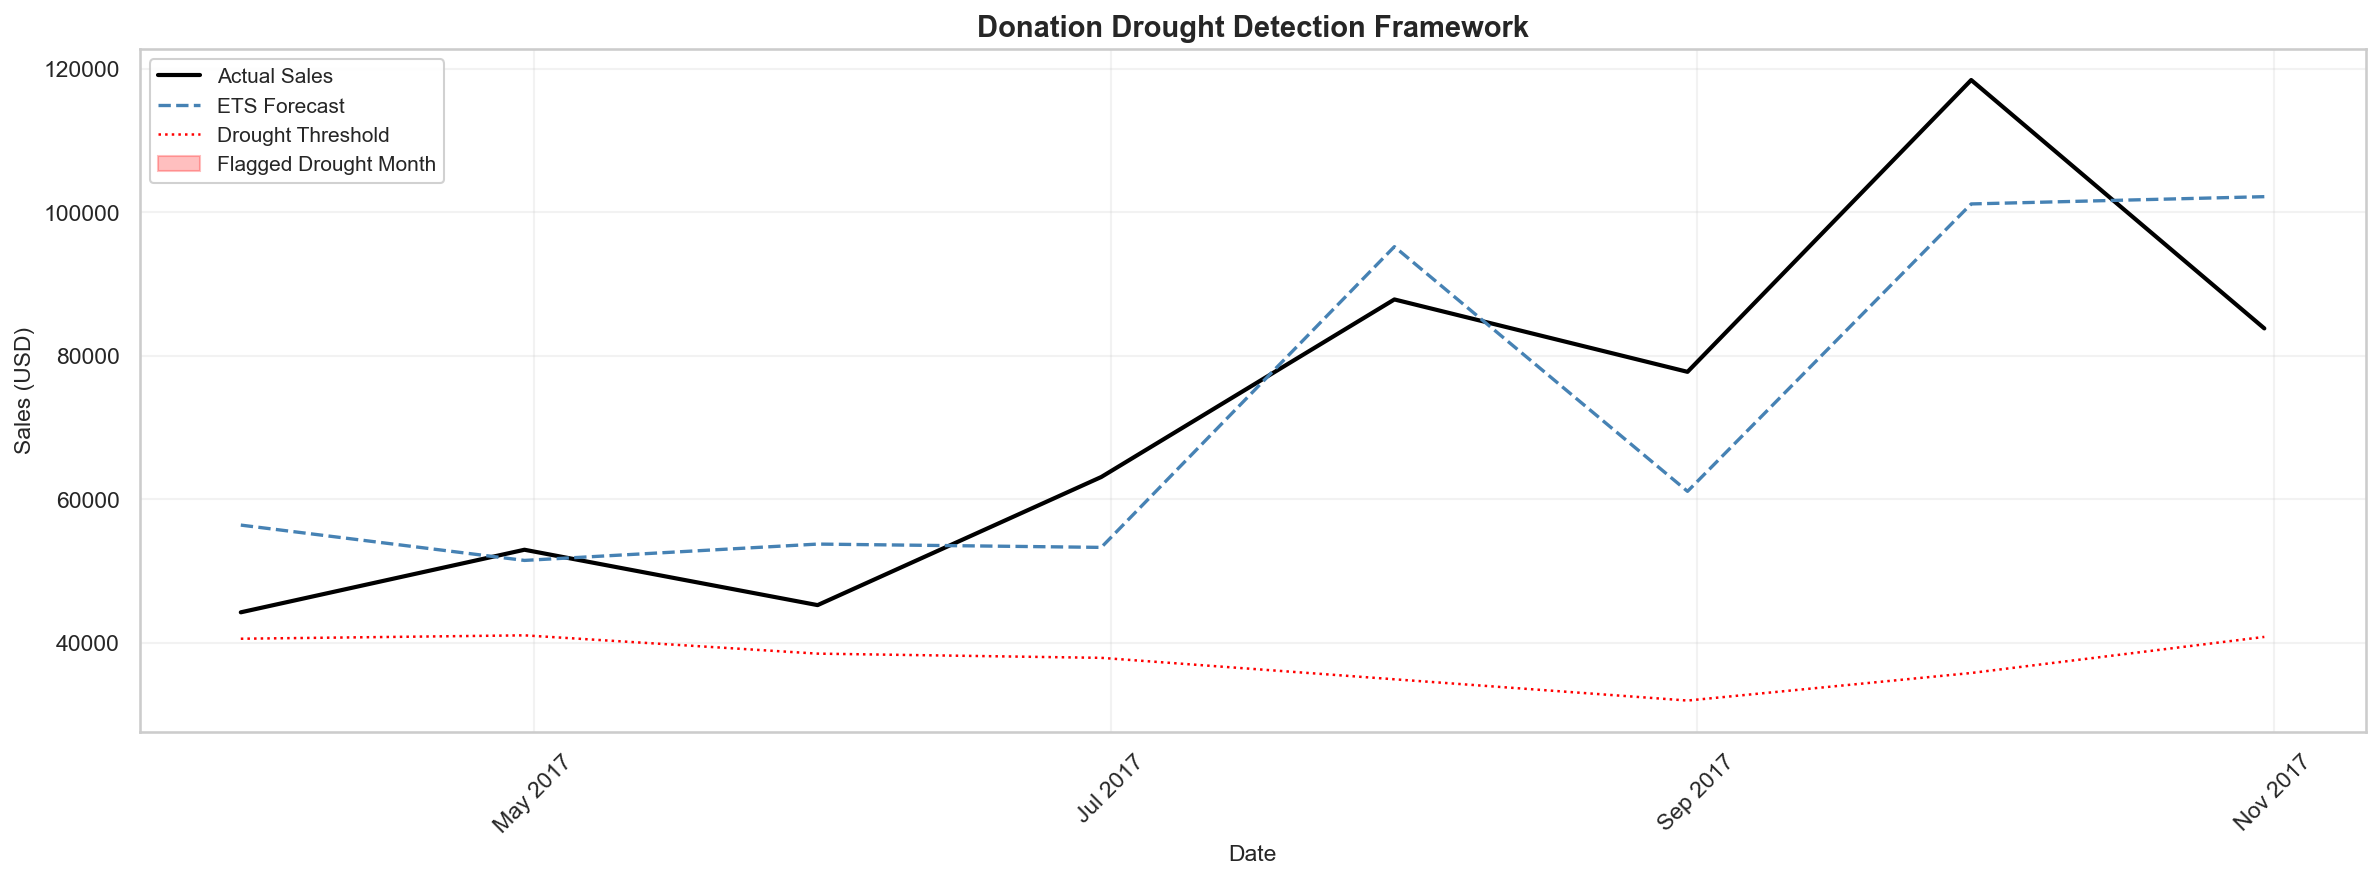

Saved: figures/fig_drought_detection.png


In [18]:
fig, ax = plt.subplots(figsize=(16, 6))

# Use the index from your forecast_series to ensure everything aligns
plot_index = forecast_series.index

ax.plot(plot_index, y_test_vals[:len(plot_index)], label='Actual Sales', color='black', linewidth=2)
ax.plot(plot_index, forecast_series, label=f'{best_model_name} Forecast', color='steelblue', linewidth=1.6, linestyle='--')
ax.plot(plot_index, threshold_test.values[:len(plot_index)], label='Drought Threshold', color='red', linewidth=1.2, linestyle=':')




for dw in drought_flags.index:
    ax.axvspan(dw - pd.DateOffset(days=15), dw + pd.DateOffset(days=15),
               alpha=0.25, color='red', zorder=0)

drought_patch = mpatches.Patch(color='red', alpha=0.25, label='Flagged Drought Month')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [drought_patch], loc='upper left', framealpha=0.9)

ax.set_title('Donation Drought Detection Framework', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('figures/fig_drought_detection.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_drought_detection.png')

## 7. Wilcoxon Signed-Rank Test — Statistical Significance

In [14]:
errors_best   = np.abs(y_test_vals - best_forecast)
errors_second = np.abs(y_test_vals - second_forecast)


diff = errors_best - errors_second
if np.all(diff == 0):
    print('Warning: all differences are zero — models produce identical errors.')
else:
    stat, p_value = stats.wilcoxon(errors_best, errors_second)
    print('Wilcoxon Signed-Rank Test')
    print(f'  Best model   : {best_model_name}')
    print(f'  Second best  : {second_model_name}')
    print(f'  Statistic    : {stat:.4f}')
    print(f'  p-value      : {p_value:.4f}')
    if p_value < 0.05:
        print(f'  -> STATISTICALLY SIGNIFICANT (p < 0.05)')
    else:
        print(f'  -> NOT statistically significant (p >= 0.05)')

Wilcoxon Signed-Rank Test
  Best model   : ETS
  Second best  : Prophet+Holidays
  Statistic    : 14.0000
  p-value      : 0.6406
  -> NOT statistically significant (p >= 0.05)


## 8. Final Master Results Table

In [15]:
print('\n================================================')
print('         FINAL MASTER RESULTS TABLE            ')
print('================================================')
print(results_df.to_string())
print('================================================')

best_mape  = results_df['MAPE'].min()
worst_mape = results_df['MAPE'].max()
worst_name = results_df['MAPE'].idxmax()
diff_pp    = round(worst_mape - best_mape, 2)

print(f'\nBest  : {best_model_name}  MAPE={best_mape}%')
print(f'Worst : {worst_name}  MAPE={worst_mape}%')
print(f'Improvement over worst: {diff_pp} percentage points')


results_df.to_csv('results_final.csv')
print('\nSaved: results_final.csv')


         FINAL MASTER RESULTS TABLE            
                      RMSE       MAE   MAPE
ETS               12677.22  11451.49  16.36
Prophet+Holidays  16335.74  13085.30  17.45
XGBoost           16364.50  13418.58  17.84
ARIMA             27751.03  22117.39  27.55
LSTM              36479.24  27765.70  31.94

Best  : ETS  MAPE=16.36%
Worst : LSTM  MAPE=31.94%
Improvement over worst: 15.58 percentage points

Saved: results_final.csv
